<a href="https://colab.research.google.com/github/astridcvr/daily-ml-practice/blob/main/day_15_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Datasets loaded.
Removing non-numeric columns: ['ORDERDATE', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'CITY', 'POSTALCODE', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

Model trained.

=== Model Performance ===
RMSE: 1019.30
R² Score: 0.7620


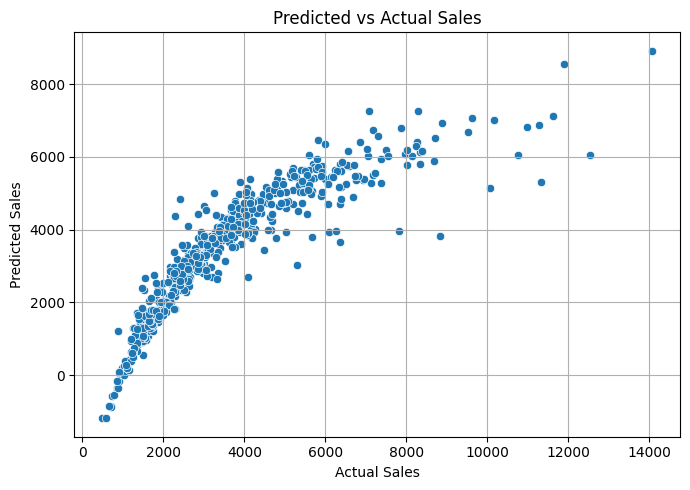


CSV generated: day15_predictions.csv


In [2]:
# ============================================================
# Day 15: Linear Regression / Jour 15 : Régression linéaire
# ============================================================

# === 1. Import libraries ===
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# === 2. Load data ===
url_X_train = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/X_train.csv"
url_X_test  = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/X_test.csv"
url_y_train = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/y_train.csv"
url_y_test  = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/y_test.csv"

X_train = pd.read_csv(url_X_train)
X_test = pd.read_csv(url_X_test)
y_train = pd.read_csv(url_y_train).values.ravel()
y_test = pd.read_csv(url_y_test).values.ravel()

print("Datasets loaded.")

# === 3. Remove non-numeric columns ===
non_numeric_cols = X_train.select_dtypes(include=["object"]).columns
print("Removing non-numeric columns:", list(non_numeric_cols))

X_train = X_train.drop(columns=non_numeric_cols)
X_test = X_test.drop(columns=non_numeric_cols)

# === 4. Train model ===
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel trained.")

# === 5. Predictions ===
y_pred = model.predict(X_test)

# === 6. Evaluation ===
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== Model Performance ===")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# === 7. Visualization ===
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Predicted vs Actual Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

# === 8. Save predictions ===
pred_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
pred_df.to_csv("day15_predictions.csv", index=False)
print("\nCSV generated: day15_predictions.csv")
